**Step 1: Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

**Step 2: Reading the Dataset**

In [ ]:
df = pd.read_excel('Sample - Superstore.xls')
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


**Step 3: Understanding Dataset Structure**

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

**Step 4: Check Missing Values**

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**Step 5: Handle Missing Values and Drop Unwanted Columns**

In [ ]:
df['Postal Code'] = df['Postal Code'].fillna(5408)
df = df.drop('Country', axis=1)

**Step 6: Segment-wise Sales – Pie Chart (Plotly)**

In [ ]:
fig = go.Figure(go.Pie(
    labels=df['Segment'],
    values=df['Sales'],
    customdata=df['Sales'],
    hovertemplate="Segment: %{label}<br>Sales: %{customdata}<extra></extra>",
    pull=[0, 0, 0, 0.1]
))

fig.update_layout(
    title={'text': "Sales in Different Segments", 'x': 0.5}
)

fig.show()

**Step 7: Count Plot for Sub-Category vs Category**

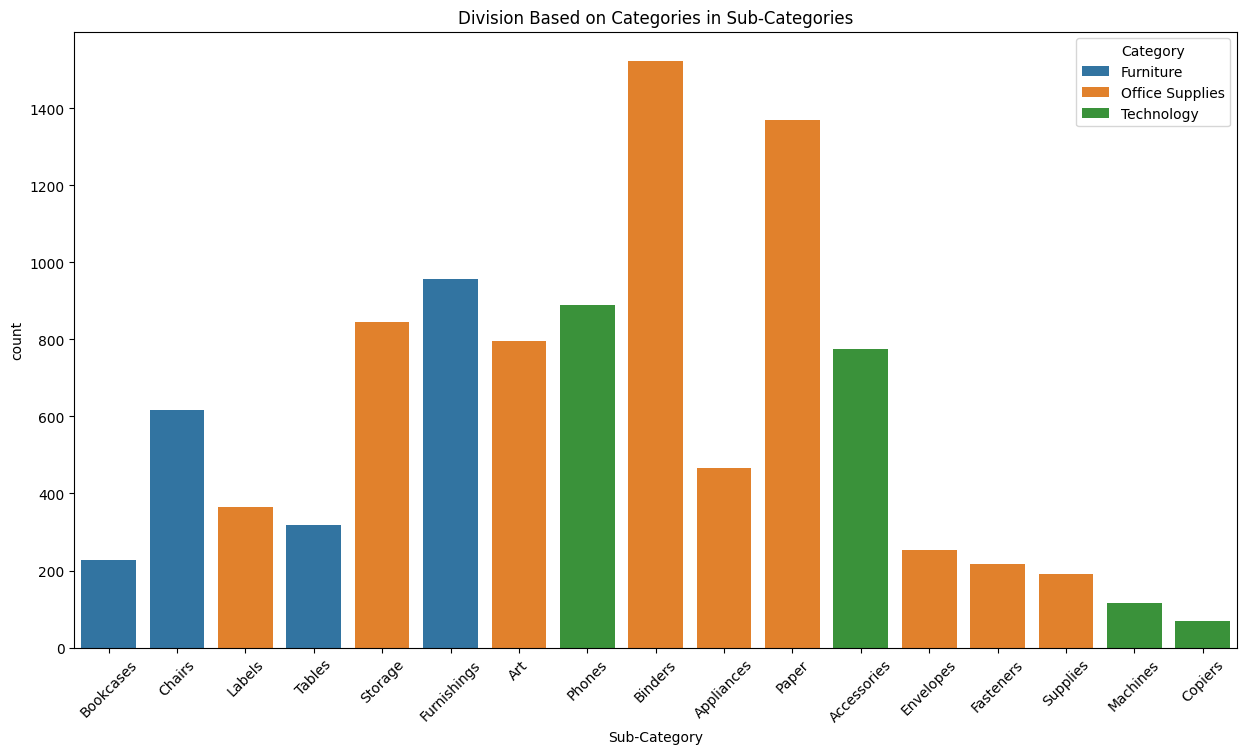

In [ ]:
plt.figure(figsize=(15,8))
sns.countplot(x='Sub-Category', hue='Category', data=df)
plt.title("Division Based on Categories in Sub-Categories")
plt.xticks(rotation=45)
plt.show()

**Step 8: Bar Chart for Ship Mode vs Sales**

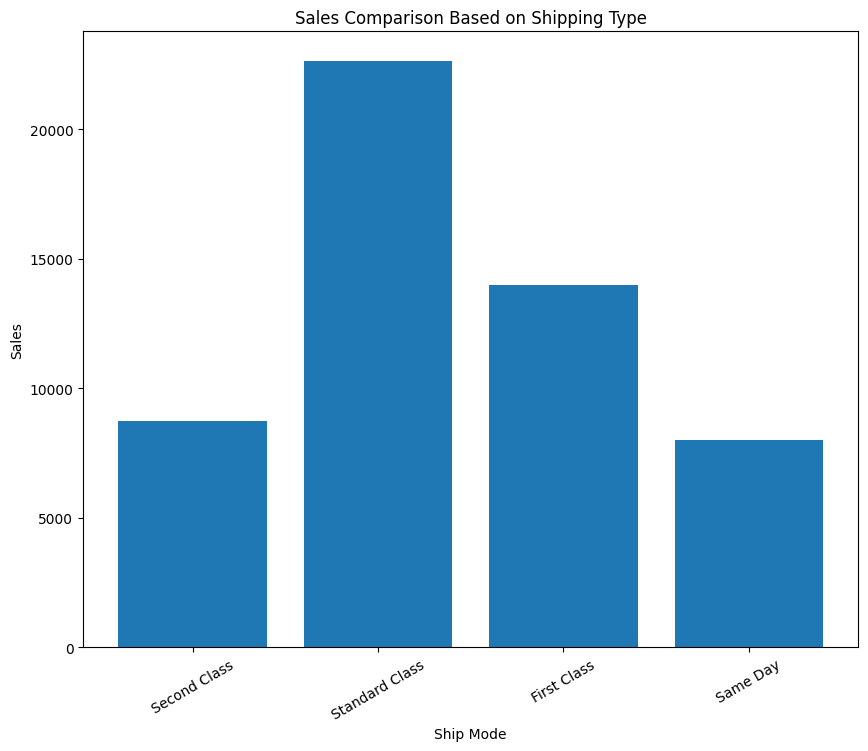

In [ ]:
plt.figure(figsize=(10,8))
plt.bar(df['Ship Mode'], df['Sales'])
plt.xlabel("Ship Mode")
plt.ylabel("Sales")
plt.title("Sales Comparison Based on Shipping Type")
plt.xticks(rotation=30)
plt.show()

**Step 9: Region-wise Count Plot**

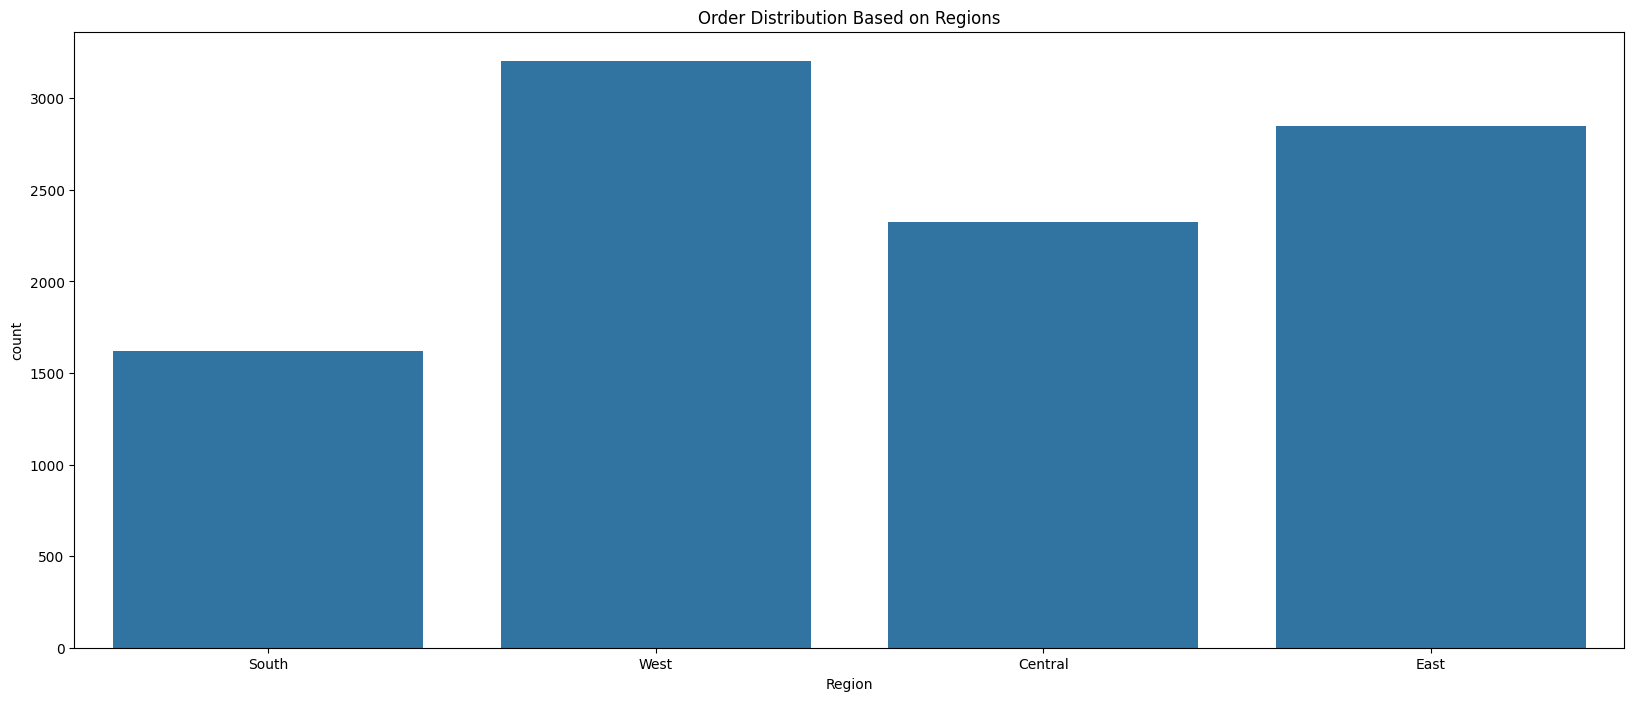

In [ ]:
plt.figure(figsize=(20,8))
sns.countplot(x='Region', data=df)
plt.title("Order Distribution Based on Regions")
plt.show()

**Step 10: Correlation Heatmap**

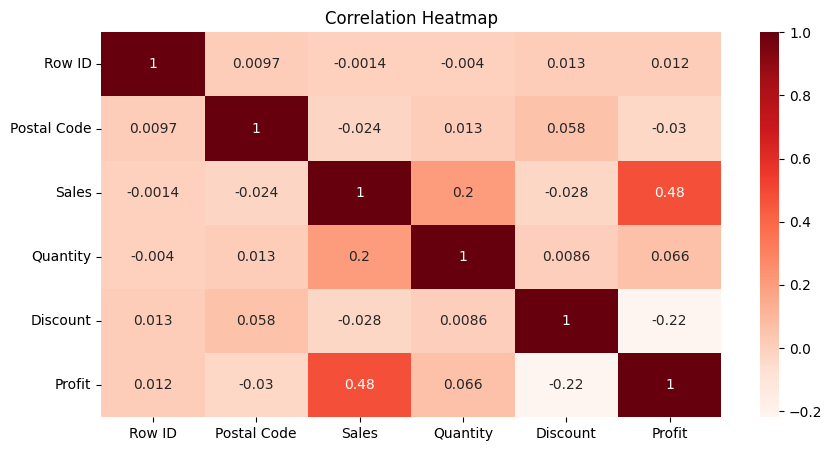

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Reds')
plt.title("Correlation Heatmap")
plt.show()

**Step 11: Remove Irrelevant Columns**

In [ ]:
df.drop(['Row ID', 'Postal Code'], axis=1, inplace=True)

**Step 12:  Facet Histogram Based on Shipping Mode**

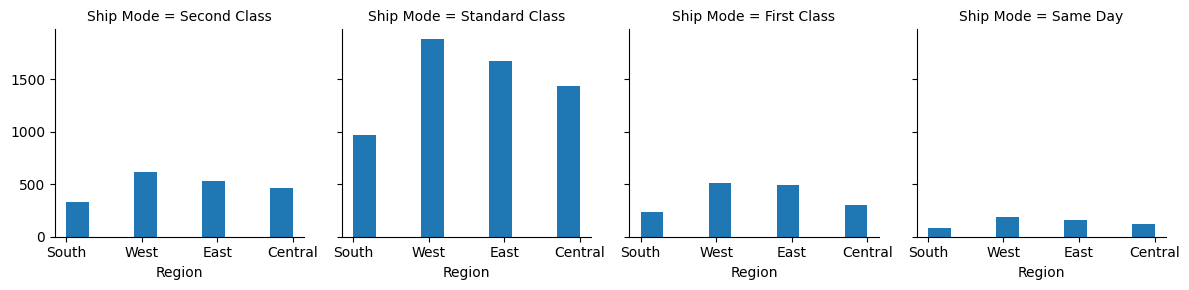

In [ ]:
region_hist = sns.FacetGrid(df, col='Ship Mode')
region_hist.map(plt.hist, 'Region')

**Step 13: Create Derived Columns**

In [ ]:
df['Cost'] = df['Sales'] - df['Profit']
df['Profit %'] = (df['Profit'] / df['Cost']) * 100
df['Order Year'] = df['Order Date'].dt.year

**Step 14: Total Quantity Sold by Sub-Category**

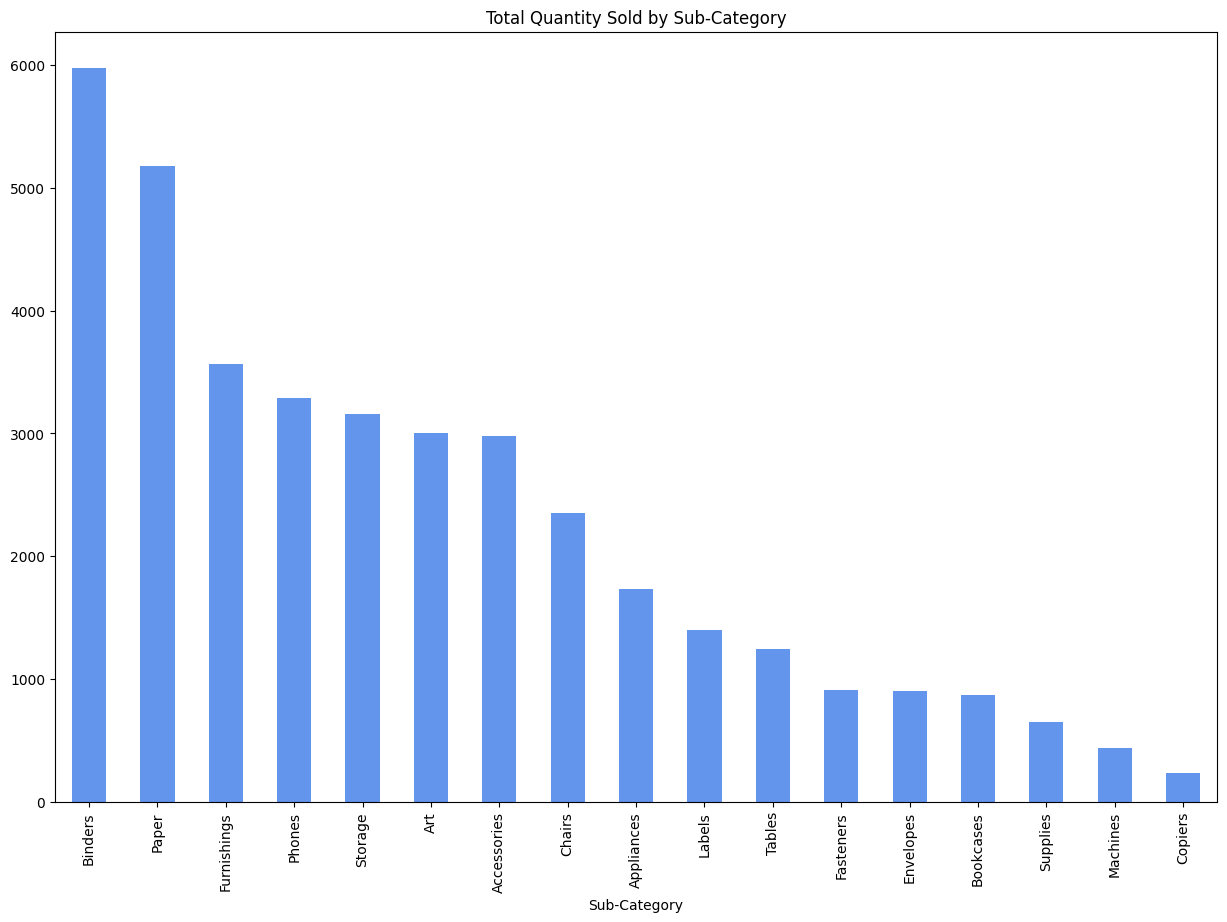

In [ ]:
df.groupby('Sub-Category')['Quantity'].sum() \
  .sort_values(ascending=False) \
  .plot(kind='bar', figsize=(15,10), color='Cornflowerblue')

plt.title("Total Quantity Sold by Sub-Category")
plt.show()

**Step 15: Region-wise Average Sales and Profit**

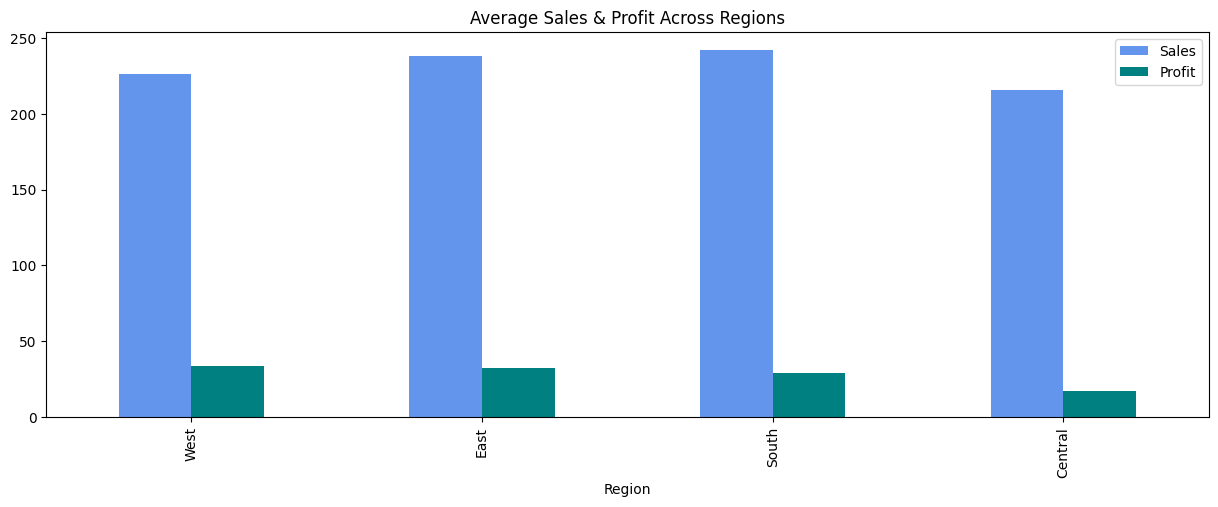

In [ ]:
df_region = df.groupby('Region')[['Sales','Discount','Profit']].mean()

df_region.sort_values('Profit', ascending=False)[['Sales','Profit']] \
         .plot(kind='bar', figsize=(15,5),
               color=['Cornflowerblue','Teal'])

plt.title("Average Sales & Profit Across Regions")
plt.show()

**Step 16: Unit Price Comparison by Sub-Category**

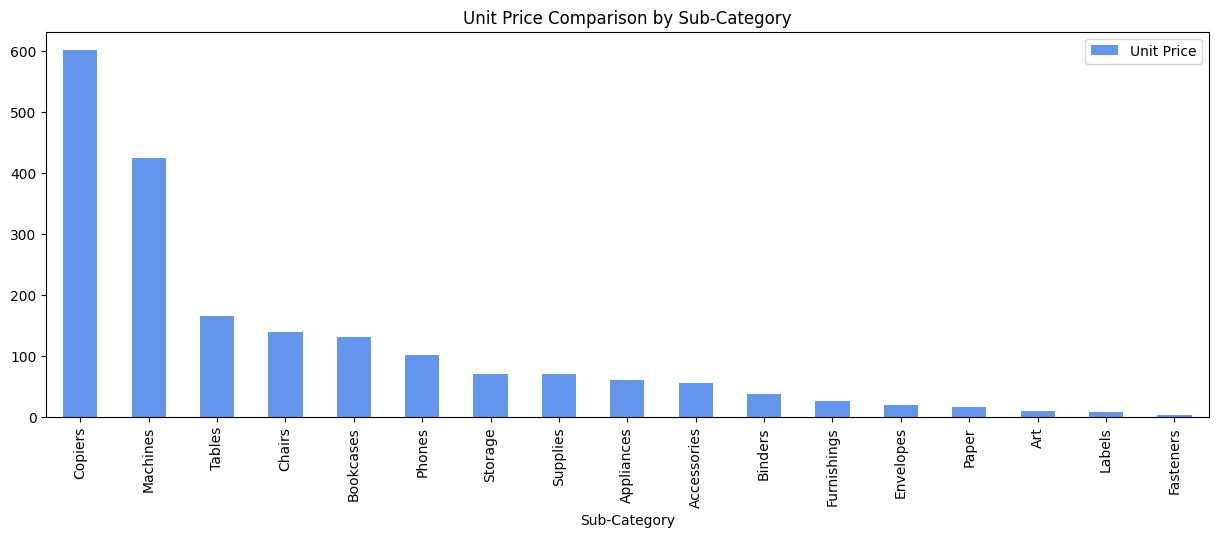

In [ ]:
df['Unit Price'] = df['Sales'] / df['Quantity']
df['Unit Profit'] = df['Profit'] / df['Quantity']

df.groupby('Sub-Category')[['Unit Price']].mean() \
  .sort_values('Unit Price', ascending=False) \
  .plot(kind='bar', figsize=(15,5), color='Cornflowerblue')

plt.title("Unit Price Comparison by Sub-Category")
plt.show()

**Step 17: Profit vs Discount Line Plot**

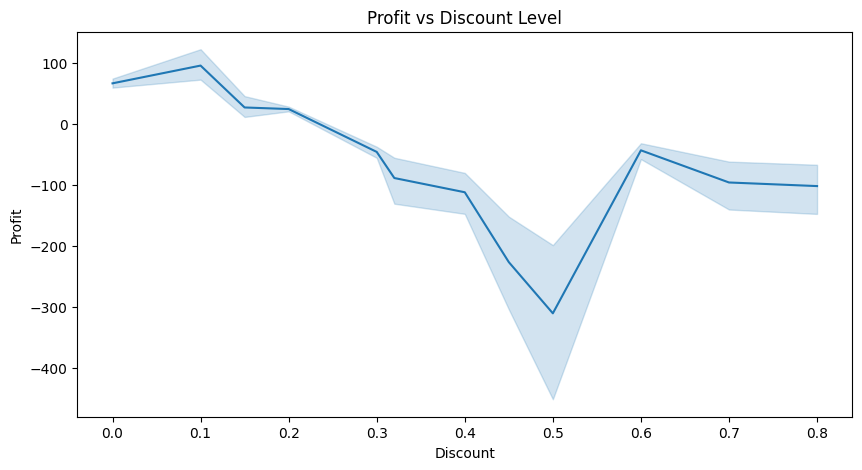

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Discount', y='Profit', data=df)
plt.title("Profit vs Discount Level")
plt.show()

**Step 18: Discounted vs Non-Discounted Transactions**

In [ ]:
df_discounted = df[df['Discount'] > 0]
df_no_discount = df[df['Discount'] == 0]

print("On Average:")
print("Discounted Sales:", round(df_discounted['Sales'].mean(), 2))
print("Non-discounted Sales:", round(df_no_discount['Sales'].mean(), 2))

print("\nIn Total:")
print("Total Discounted Sales:", round(df_discounted['Sales'].sum(), 2))
print("Total Non-Discounted Sales:", round(df_no_discount['Sales'].sum(), 2))


On Average:
Discounted Sales: 232.74
Non-discounted Sales: 226.74

In Total:
Total Discounted Sales: 1209292.39
Total Non-Discounted Sales: 1087908.47
